In [1]:
# 1) ensure Python can see your project root
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("→ Added to sys.path:", project_root)
print("→ cwd is:", os.getcwd())

from environments.auv_env.auv_env    import AUVEnv
from environments.auv_env.auv_config import AUVEnvConfig
from agents.auv_dqn_agent    import AuvDQNAgent
from agents.enhanced_dqn_agent import EnhancedDQNAgent
from agents.td3_agent       import TD3Agent
from agents.dqn_agent      import train_dqn
from environments.grid_env.grid_utils     import plot_rewards
from utils.shared_utils import evaluate_agent
from utils.graphics_utils import record_headless

→ Added to sys.path: /Users/eirikvarnes/code/auv-rl-project
→ cwd is: /Users/eirikvarnes/code/auv-rl-project/notebooks
pygame 2.6.1 (SDL 2.28.4, Python 3.11.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
static_cfg = AUVEnvConfig()
static_env = AUVEnv(static_cfg)

static_agent = AuvDQNAgent(
    static_env,
    hidden_dims=[64, 64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=20000,
    target_update=20,
)


DQN Training: 100%|██████████| 500/500 [02:08<00:00,  3.90it/s, Reward=422.0, ε=0.082]  


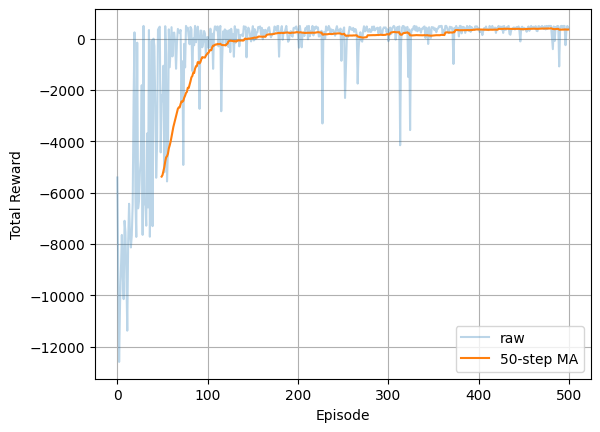

In [6]:
rewards = train_dqn(static_env, static_agent, episodes=500, max_steps= 500)
plot_rewards(rewards, window=50)
static_agent.save("../models/static_auv_dqn.pth")

In [3]:
static_agent.load("../models/static_auv_dqn.pth")

In [4]:
record_headless(static_env, static_agent, out_path='../gifs/static_auv.gif')

Headless recording saved to ../gifs/static_auv.gif


In [5]:
sr, avg_steps = evaluate_agent(static_env, static_agent, episodes = 500, max_steps=500)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 99.6%, Avg steps: 34.0


In [6]:
actions = [
    (0.15,  0.0),  # forward
    (0.15,  0.15),  # forward + left
    (0.15, -0.15),  # forward + right
    (0.0,  0.15),  # in-place left turn
    (0.0, -0.15),  # in-place right turn
]


random_cfg = AUVEnvConfig(random_map=True, 
                          dock_radius=0.2, 
                          spawn_clearance=0.5,
                          wall_penalty_coeff=5.0,
                          wall_thresh=1.0,
                          collision_penalty=5.0, 
                          turn_penalty_coeff= 1.0,
                          progress_coeff= 1.0,
                          use_discrete_actions = actions,
                          )

random_env = AUVEnv(random_cfg)

random_agent = AuvDQNAgent(
    random_env,
    hidden_dims=[256,256,128],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=128,
    buffer_size=20000,
    target_update=40,
)


DQN Training: 100%|██████████| 3000/3000 [09:37<00:00,  5.19it/s, Reward=452.6, ε=0.010]  


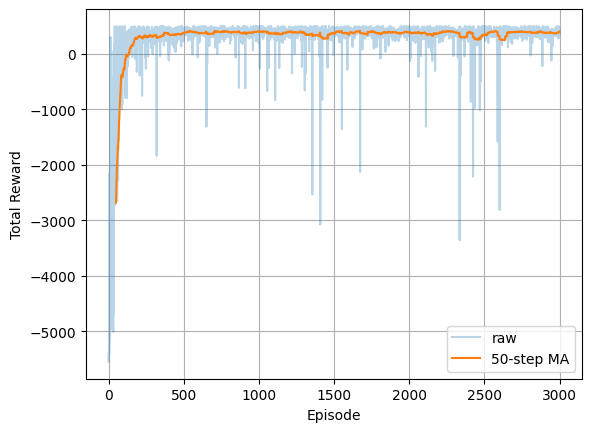

In [ ]:
rewards = train_dqn(random_env, random_agent, episodes=3000, max_steps=1000)
plot_rewards(rewards, window=50)
random_agent.save("../models/random_auv_dqn.pth")

In [8]:
record_headless(random_env, random_agent, out_path='../gifs/random_auv.gif')

Headless recording saved to ../gifs/random_auv.gif


In [7]:
random_agent.load("../models/random_auv_dqn.pth")

In [9]:
sr, avg_steps = evaluate_agent(random_env, 
                               random_agent, 
                               episodes = 500, 
                               max_steps=500
                               )

print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 86.2%, Avg steps: 33.2


In [10]:
test_random_env = AUVEnv(random_cfg)


In [ ]:
record_headless(test_random_env, random_agent, out_path='../gifs/test_random_auv.gif')

In [ ]:
sr, avg_steps = evaluate_agent(test_random_env, 
                               random_agent, 
                               episodes = 100, 
                               max_steps=500
                               )

print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 92.0%, Avg steps: 33.0
